In [ ]:
import pandas as pd
from pathlib import Path

In [10]:
PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day5_standardized_supply_data.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/day7_clean_supply_data.csv"


df = pd.read_csv(INPUT_FILE)

print("Dataset shape:", df.shape)

Dataset shape: (10257, 8)


In [11]:
missing_summary = df.isnull().sum()

print("Missing values per column")
print(missing_summary)

Missing values per column
batch_id              0
vendor_name           0
product_name          0
quantity              0
unit                  0
cost_per_kg         205
defect_rate_pct       0
procurement_date      0
dtype: int64


In [13]:
missing_cost = df[df["cost_per_kg"].isnull()]

print("Rows with missing cost:", len(missing_cost))

Rows with missing cost: 205


In [12]:
report_path = PROJECT_ROOT / "05_corporate_governance/day7_missing_value_report.txt"

with open(report_path, "w") as f:
    
    f.write("HONEYRICH DATA QUALITY REPORT - DAY 7\n")
    f.write("=====================================\n\n")
    
    f.write("Missing Values Per Column\n")
    f.write("-------------------------\n")
    
    f.write(str(missing_summary))

print("Report saved:", report_path)

Report saved: D:\Coding\New folder\05_corporate_governance\day7_missing_value_report.txt


In [14]:
median_cost = df["cost_per_kg"].median()

print("Median cost per kg:", median_cost)

Median cost per kg: 310.815


In [15]:
df["cost_per_kg"] = df["cost_per_kg"].fillna(median_cost)

In [16]:
print(df["cost_per_kg"].isnull().sum())

0


In [17]:
#total_procurement_cost
df["total_procurement_cost"] = df["cost_per_kg"] * df["quantity"]

In [18]:
Q1 = df["cost_per_kg"].quantile(0.25)
Q3 = df["cost_per_kg"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

cost_outliers = df[(df["cost_per_kg"] < lower) | (df["cost_per_kg"] > upper)]

print("Cost outliers:", len(cost_outliers))

Cost outliers: 217


In [19]:
cost_outliers.to_csv(
    PROJECT_ROOT / "03_processed_data/cost_outliers_detected.csv",
    index=False
)

print("Outlier dataset saved")

Outlier dataset saved


In [20]:
total_rows = len(df)

outlier_percentage = (len(cost_outliers) / total_rows) * 100

print("Outlier percentage:", round(outlier_percentage,2), "%")

Outlier percentage: 2.12 %


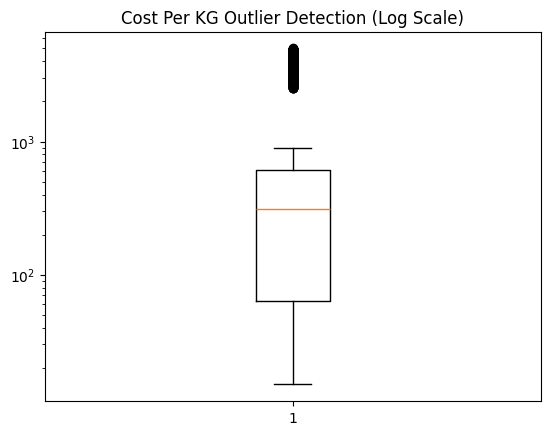

In [23]:
plt.figure()

plt.boxplot(df["cost_per_kg"])

plt.yscale("log")

plt.title("Cost Per KG Outlier Detection (Log Scale)")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/cost_outlier_logscale.png"
)
plt.show()
plt.close()

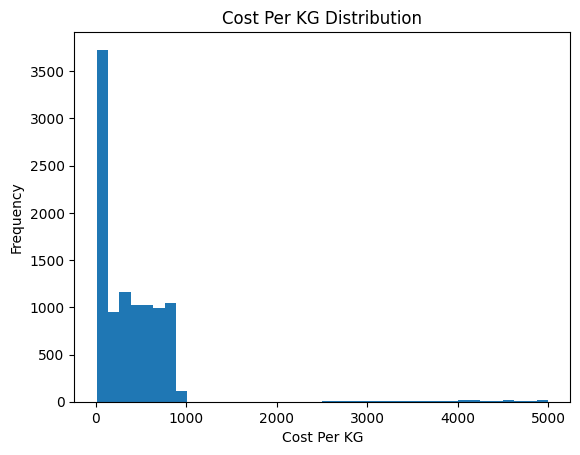

In [25]:
plt.figure()

plt.hist(df["cost_per_kg"], bins=40)

plt.title("Cost Per KG Distribution")

plt.xlabel("Cost Per KG")
plt.ylabel("Frequency")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/cost_distribution_histogram.png"
)
plt.show()
plt.close()

In [26]:
vendor_quality = df.groupby("vendor_name").agg({

    "quantity": "sum",
    "cost_per_kg": "mean",
    "defect_rate_pct": "mean"

}).reset_index()

vendor_quality.to_csv(
    PROJECT_ROOT / "03_processed_data/vendor_quality_metrics.csv",
    index=False
)

In [28]:
df.to_csv(
    PROJECT_ROOT / "03_processed_data/day7_clean_supply_data.csv",
    index=False
)